In [ ]:
# I will be incorporating all features using balanced_dataset.csv.
# This implementation is based on Joel's original MoE architecture with several modifications.
# Modifications:
# - Increased training from 30 to 100 epochs (similar to Audrey's implementation).
# - Implemented 5-fold stratified cross-validation instead of a single train/validation split.
# - Replaced BatchNorm with LayerNorm to avoid issues with small batch sizes.
# - Added L1 and L2 regularization.
# - Switched from regression to binary classification by predicting the dataset label (0/1)
#   rather than a continuous target variable, allowing evaluation with classification
#   metrics such as Accuracy, Precision, Recall, and F1-score.

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload zip file


MessageError: TypeError: Cannot read properties of undefined (reading 'next')

In [ ]:
DATA_CSV = "/content/balanced_dataset.csv"

In [ ]:
# ML Libs
import torch
import torch.nn as nn
from torch.distributions.normal import Normal
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from torch.utils.data import Dataset, DataLoader

# File processing stuff
import os
from pathlib import Path

# To help w/ L1 and L2
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('--l1_reg', type=float, default=0.01, help="L1 regularization strength")
parser.add_argument('--l2_reg', type=float, default=5e-4, help="L2 regularization strength")
args, unknown = parser.parse_known_args()

L1_REG = args.l1_reg
L2_REG = args.l2_reg

# --- GLOBAL OUTPUT DIRECTORY (Google Drive) ---
# Mounting Drive makes OUTPUT_DIR persistent across Colab sessions/runtime
# resets, instead of living in the ephemeral local Colab filesystem.
# This is the fix for the NameError you were hitting: OUTPUT_DIR is now
# defined once, at the top, and used everywhere (per-fold saves + final saves).
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/riboMoE_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"All outputs will be saved to: {OUTPUT_DIR}")

# For reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# STEP 1: Data loading/processing, redoing this so that it can take balanced_dataset.csv
def load_and_combine_data(csv_path):
    print(f"Loading dataset from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Ensure label column exists (like Audrey's code)
    if "label" not in df.columns:
        raise ValueError("Expected a 'label' column in balanced_dataset.csv.")

    print(f"Dataset shape: {df.shape}")
    print("Label counts:\n", df['label'].value_counts())

    return df


# STEP 2: Model definition
# As per Professor's request, I was modifying the model in this github:
# https://github.com/davidmrau/mixture-of-experts/blob/master/moe.py
# ^^^^ This is main inspiration for the model
# https://cameronrwolfe.substack.com/p/nano-moe <-- this can also be a good read
# but i wasn't fully sure how to implement/use

# This helper class is part of the original MoE architecture
class SparseDispatcher:
    def __init__(self, num_experts, gates):
        self._gates, self._num_experts = gates, num_experts
        sorted_experts, index_sorted_experts = torch.nonzero(gates).sort(0)
        _, self._expert_index = sorted_experts.split(1, dim=1)
        self._batch_index = torch.nonzero(gates)[index_sorted_experts[:, 1], 0]
        self._part_sizes = (gates > 0).sum(0).tolist()
        gates_exp = gates[self._batch_index.flatten()]
        self._nonzero_gates = torch.gather(gates_exp, 1, self._expert_index)

    def dispatch(self, inp):
        inp_exp = inp[self._batch_index].squeeze(1)
        return torch.split(inp_exp, self._part_sizes, dim=0)

    def combine(self, expert_out, multiply_by_gates=True):
        stitched = torch.cat(expert_out, 0)
        stitched = (
            stitched.mul(self._nonzero_gates)
            if multiply_by_gates else stitched
        )
        zeros = torch.zeros(
            self._gates.size(0),
            expert_out[-1].size(1),
            requires_grad=True,
            device=stitched.device
        )
        combined = zeros.index_add(0, self._batch_index, stitched.float())
        return combined


# Modifying the MLP in that Sparesely gated structure from the github repo
class EnhancedMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, dropout_prob=0.3):
        super(EnhancedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size // 2, output_size)
        )

    def forward(self, x):
        return self.net(x)


# Main Mixture of Experts model
class MoE(nn.Module):
    def __init__(
        self,
        input_size,
        output_size,
        num_experts,
        hidden_size,
        noisy_gating=True,
        k=4
    ):
        super(MoE, self).__init__()
        self.noisy_gating = noisy_gating
        self.num_experts = num_experts
        self.k = k

        self.experts = nn.ModuleList([
            EnhancedMLP(input_size, output_size, hidden_size)
            for _ in range(self.num_experts)
        ])

        self.w_gate = nn.Parameter(
            torch.zeros(input_size, num_experts),
            requires_grad=True
        )
        self.w_noise = nn.Parameter(
            torch.zeros(input_size, num_experts),
            requires_grad=True
        )

        self.softplus = nn.Softplus()
        self.softmax = nn.Softmax(1)
        self.register_buffer("mean", torch.tensor([0.0]))
        self.register_buffer("std", torch.tensor([1.0]))

    def cv_squared(self, x):
        eps = 1e-10
        if x.shape[0] == 1:
            return torch.tensor([0], device=x.device, dtype=x.dtype)
        return x.float().var() / (x.float().mean() ** 2 + eps)

    def noisy_top_k_gating(self, x, train, noise_epsilon=1e-2):
        clean_logits = x @ self.w_gate
        logits = clean_logits

        if self.noisy_gating and train:
            raw_noise_stddev = x @ self.w_noise
            noise_stddev = self.softplus(raw_noise_stddev) + noise_epsilon
            noisy_logits = clean_logits + (
                torch.randn_like(clean_logits) * noise_stddev
            )
            logits = noisy_logits

        logits = self.softmax(logits)
        top_logits, top_indices = logits.topk(
            min(self.k + 1, self.num_experts),
            dim=1
        )
        top_k_logits = top_logits[:, :self.k]
        top_k_indices = top_indices[:, :self.k]
        top_k_gates = top_k_logits / (
            top_k_logits.sum(1, keepdim=True) + 1e-6
        )

        zeros = torch.zeros_like(logits, requires_grad=True)
        gates = zeros.scatter(1, top_k_indices, top_k_gates)
        load = (gates > 0).sum(0)

        return gates, load

    def forward(self, x, loss_coef=1e-2):
        gates, load = self.noisy_top_k_gating(x, self.training)
        importance = gates.sum(0)

        loss = self.cv_squared(importance) + self.cv_squared(load)
        loss *= loss_coef

        dispatcher = SparseDispatcher(self.num_experts, gates)
        expert_inputs = dispatcher.dispatch(x)
        expert_outputs = [
            self.experts[i](expert_inputs[i])
            for i in range(self.num_experts)
        ]
        y = dispatcher.combine(expert_outputs)

        return y, loss


# STEP 3 & 4: Data set preparation and training
class RiboswitchDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


def calculate_classification_metrics(targets, logits):
    probabilities = torch.sigmoid(torch.tensor(logits)).numpy()
    predicted_labels = (probabilities >= 0.5).astype(int)
    targets = np.asarray(targets).astype(int)

    return {
        "accuracy": accuracy_score(targets, predicted_labels),
        "precision": precision_score(
            targets, predicted_labels, zero_division=0
        ),
        "recall": recall_score(
            targets, predicted_labels, zero_division=0
        ),
        "f1": f1_score(
            targets, predicted_labels, zero_division=0
        )
    }


if __name__ == "__main__":
    # --- Data Paths ---
    # Use a locally uploaded CSV (Colab upload)
    DATA_CSV = "/content/balanced_dataset.csv"

    # Check that the file exists before loading
    if not os.path.exists(DATA_CSV):
        raise FileNotFoundError(
            f"Could not find {DATA_CSV}. "
            "Please upload balanced_dataset.csv to the Colab session."
        )

    master_df = load_and_combine_data(DATA_CSV)

    # --- Preprocess Data ---
    print("\nPreprocessing data...")

    NUMERICAL_FEATURES = [
        "salt_molarity", "temperature (Celsius)",
        "trigger_target_binding_percentage",
        "switch_energy", "target_energy", "reporter_energy",
        "complex_energy",
        "switch_gc", "switch_at", "target_gc", "target_at",
        "reporter_gc", "reporter_at", "complex_gc", "complex_at",
        "switch_ensemble_defect", "target_ensemble_defect",
        "reporter_ensemble_defect",
        "complex_ensemble_defect", "switch_single_strandedness",
        "target_single_strandedness",
        "reporter_single_strandedness",
        "complex_single_strandedness",
        "trigger_single_strandedness",
        "rbs_location", "loop_energy"
    ]

    master_df[NUMERICAL_FEATURES] = (
        master_df[NUMERICAL_FEATURES].fillna(0)
    )

    def one_hot_encode(seq, pad_char="N", max_len=210):
        base_to_vec = {
            'A': [1, 0, 0, 0],
            'C': [0, 1, 0, 0],
            'G': [0, 0, 1, 0],
            'T': [0, 0, 0, 1],
            'U': [0, 0, 0, 1],
            'N': [0, 0, 0, 0]
        }

        encoded_list = []

        for s in seq:
            s = str(s)
            padded_seq = s[:max_len].ljust(max_len, pad_char)
            encoded = [
                base_to_vec.get(base, [0, 0, 0, 0])
                for base in padded_seq
            ]
            encoded_list.append(np.array(encoded).flatten())

        return np.array(encoded_list)

    encoded_seqs = one_hot_encode(
        master_df["complex_nucelotides"]
    )
    encoded_seq_df = pd.DataFrame(
        encoded_seqs,
        columns=[
            f"base_{i}"
            for i in range(encoded_seqs.shape[1])
        ]
    )

    X = pd.concat(
        [
            master_df[NUMERICAL_FEATURES].reset_index(drop=True),
            encoded_seq_df.reset_index(drop=True)
        ],
        axis=1
    ).values.astype(np.float32)

    y = master_df["label"].values.astype(np.float32)

    print("Data successfully preprocessed.")
    print(f"Feature matrix shape (X): {X.shape}")

    # --- Independent Train/Test Split ---
    # Keep the test segment completely separate from cross-validation.
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y
    )

    print(f"Train + validation shape: {X_train_val.shape}")
    print(f"Independent test shape: {X_test.shape}")

    # --- 5-Fold Cross Validation ---
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    EPOCHS = 100
    BATCH_SIZE = 128
    NUM_NUMERICAL_FEATURES = len(NUMERICAL_FEATURES)
    fold_results = []

    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    print(f"Using device: {device}")

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train_val, y_train_val)
    ):
        print(f"\n--- Fold {fold + 1} ---")

        X_train = X_train_val[train_idx].copy()
        X_val = X_train_val[val_idx].copy()
        y_train = y_train_val[train_idx]
        y_val = y_train_val[val_idx]

        # Fit the scaler only on this fold's training data.
        # Then apply that fitted scaler to validation data.
        scaler = StandardScaler()
        X_train[:, :NUM_NUMERICAL_FEATURES] = scaler.fit_transform(
            X_train[:, :NUM_NUMERICAL_FEATURES]
        )
        X_val[:, :NUM_NUMERICAL_FEATURES] = scaler.transform(
            X_val[:, :NUM_NUMERICAL_FEATURES]
        )

        train_dataset = RiboswitchDataset(X_train, y_train)
        val_dataset = RiboswitchDataset(X_val, y_val)

        train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False
        )
        val_loader = DataLoader(
            dataset=val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            drop_last=False
        )

        INPUT_SIZE = X.shape[1]
        OUTPUT_SIZE = 1

        model = MoE(
            input_size=INPUT_SIZE,
            output_size=OUTPUT_SIZE,
            num_experts=8,
            hidden_size=512,
            k=2
        ).to(device)

        # BCEWithLogitsLoss is used because this is binary classification.
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=1e-4
        )

        # For saving metrics per epoch
        train_losses = []
        val_losses = []
        train_accuracy_list = []
        val_accuracy_list = []
        train_precision_list = []
        val_precision_list = []
        train_recall_list = []
        val_recall_list = []
        train_f1_list = []
        val_f1_list = []

        # --- Modified Training Loop ---
        for epoch in range(EPOCHS):
            model.train()
            epoch_train_loss = 0.0
            train_targets = []
            train_logits = []

            for inputs, targets in train_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                optimizer.zero_grad()

                logits, load_balancing_loss = model(inputs)
                logits = logits.squeeze(-1)

                classification_loss = criterion(
                    logits,
                    targets.float()
                )

                # Add L1 and L2 regularization terms
                l2_loss = sum(
                    torch.sum(param ** 2)
                    for param in model.parameters()
                )
                l1_loss = sum(
                    torch.sum(torch.abs(param))
                    for param in model.parameters()
                )

                total_loss = (
                    classification_loss
                    + load_balancing_loss
                    + L2_REG * l2_loss
                    + L1_REG * l1_loss
                )

                total_loss.backward()
                optimizer.step()

                epoch_train_loss += (
                    total_loss.item() * inputs.size(0)
                )
                train_targets.extend(
                    targets.detach().cpu().numpy()
                )
                train_logits.extend(
                    logits.detach().cpu().numpy()
                )

            epoch_train_loss /= len(train_dataset)

            train_metrics = calculate_classification_metrics(
                train_targets,
                train_logits
            )

            model.eval()
            val_targets = []
            val_logits = []
            epoch_val_loss = 0.0

            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device)

                    logits, _ = model(inputs)
                    logits = logits.squeeze(-1)

                    loss_val = criterion(
                        logits,
                        targets.float()
                    )

                    epoch_val_loss += (
                        loss_val.item() * inputs.size(0)
                    )
                    val_targets.extend(
                        targets.detach().cpu().numpy()
                    )
                    val_logits.extend(
                        logits.detach().cpu().numpy()
                    )

            epoch_val_loss /= len(val_dataset)

            val_metrics = calculate_classification_metrics(
                val_targets,
                val_logits
            )

            train_losses.append(epoch_train_loss)
            val_losses.append(epoch_val_loss)
            train_accuracy_list.append(
                train_metrics["accuracy"]
            )
            val_accuracy_list.append(
                val_metrics["accuracy"]
            )
            train_precision_list.append(
                train_metrics["precision"]
            )
            val_precision_list.append(
                val_metrics["precision"]
            )
            train_recall_list.append(
                train_metrics["recall"]
            )
            val_recall_list.append(
                val_metrics["recall"]
            )
            train_f1_list.append(train_metrics["f1"])
            val_f1_list.append(val_metrics["f1"])

            print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Fold {fold + 1} | "
                f"Train Loss: {epoch_train_loss:.4f}, "
                f"Train Acc: {train_metrics['accuracy']:.4f}, "
                f"Train F1: {train_metrics['f1']:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}, "
                f"Val Acc: {val_metrics['accuracy']:.4f}, "
                f"Val F1: {val_metrics['f1']:.4f}"
            )

        # Save metrics for this fold -- now using the global OUTPUT_DIR
        np.save(f"{OUTPUT_DIR}/train_losses_fold{fold+1}.npy", np.array(train_losses))
        np.save(f"{OUTPUT_DIR}/val_losses_fold{fold+1}.npy", np.array(val_losses))

        np.save(f"{OUTPUT_DIR}/train_accuracy_fold{fold+1}.npy", np.array(train_accuracy_list))
        np.save(f"{OUTPUT_DIR}/val_accuracy_fold{fold+1}.npy", np.array(val_accuracy_list))

        np.save(f"{OUTPUT_DIR}/train_precision_fold{fold+1}.npy", np.array(train_precision_list))
        np.save(f"{OUTPUT_DIR}/val_precision_fold{fold+1}.npy", np.array(val_precision_list))

        np.save(f"{OUTPUT_DIR}/train_recall_fold{fold+1}.npy", np.array(train_recall_list))
        np.save(f"{OUTPUT_DIR}/val_recall_fold{fold+1}.npy", np.array(val_recall_list))

        np.save(f"{OUTPUT_DIR}/train_f1_fold{fold+1}.npy", np.array(train_f1_list))
        np.save(f"{OUTPUT_DIR}/val_f1_fold{fold+1}.npy", np.array(val_f1_list))

        fold_results.append({
            "fold": fold + 1,
            "val_accuracy": val_accuracy_list[-1],
            "val_precision": val_precision_list[-1],
            "val_recall": val_recall_list[-1],
            "val_f1": val_f1_list[-1],
        })

    # --- Aggregate CV metrics across folds ---
    avg_accuracy = np.mean([r["val_accuracy"] for r in fold_results])
    avg_precision = np.mean([r["val_precision"] for r in fold_results])
    avg_recall = np.mean([r["val_recall"] for r in fold_results])
    avg_f1 = np.mean([r["val_f1"] for r in fold_results])

    # Save the per-fold summary too, so it's not just printed and lost
    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df.to_csv(f"{OUTPUT_DIR}/cv_fold_summary.csv", index=False)

    print("\n===== 5-Fold CV Average Metrics =====")
    print(f"Accuracy:  {avg_accuracy:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall:    {avg_recall:.4f}")
    print(f"F1-score:  {avg_f1:.4f}")

    # fianl retrain
    print(
        "\n===== Retraining Final Model on Train + Validation Data ====="
    )

    # Fit the final scaler on Train + Validation only.
    # The independent test set is transformed but never used to fit it.
    final_scaler = StandardScaler()

    X_train_val_scaled = X_train_val.copy()
    X_test_scaled = X_test.copy()

    X_train_val_scaled[:, :NUM_NUMERICAL_FEATURES] = (
        final_scaler.fit_transform(
            X_train_val_scaled[:, :NUM_NUMERICAL_FEATURES]
        )
    )
    X_test_scaled[:, :NUM_NUMERICAL_FEATURES] = (
        final_scaler.transform(
            X_test_scaled[:, :NUM_NUMERICAL_FEATURES]
        )
    )

    full_dataset = RiboswitchDataset(
        X_train_val_scaled,
        y_train_val
    )
    full_loader = DataLoader(
        full_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False
    )

    test_dataset = RiboswitchDataset(
        X_test_scaled,
        y_test
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False
    )

    INPUT_SIZE = X.shape[1]
    OUTPUT_SIZE = 1

    final_model = MoE(
        input_size=INPUT_SIZE,
        output_size=OUTPUT_SIZE,
        num_experts=8,
        hidden_size=512,
        k=2
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=1e-4
    )

    final_train_losses = []

    for epoch in range(EPOCHS):
        final_model.train()
        epoch_loss = 0.0

        for inputs, targets in full_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            logits, load_balancing_loss = final_model(inputs)
            logits = logits.squeeze(-1)

            classification_loss = criterion(
                logits,
                targets.float()
            )

            # Add L1 and L2 regularization terms
            l2_loss = sum(
                torch.sum(param ** 2)
                for param in final_model.parameters()
            )
            l1_loss = sum(
                torch.sum(torch.abs(param))
                for param in final_model.parameters()
            )

            total_loss = (
                classification_loss
                + load_balancing_loss
                + L2_REG * l2_loss
                + L1_REG * l1_loss
            )

            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item() * inputs.size(0)

        epoch_loss /= len(full_dataset)
        final_train_losses.append(epoch_loss)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Final Train Loss: {epoch_loss:.4f}"
        )

    # independent test
    final_model.eval()
    test_targets = []
    test_logits = []
    test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits, _ = final_model(inputs)
            logits = logits.squeeze(-1)

            loss = criterion(
                logits,
                targets.float()
            )
            test_loss += loss.item() * inputs.size(0)

            test_targets.extend(
                targets.detach().cpu().numpy()
            )
            test_logits.extend(
                logits.detach().cpu().numpy()
            )

    test_loss /= len(test_dataset)

    test_metrics = calculate_classification_metrics(
        test_targets,
        test_logits
    )

    test_probabilities = torch.sigmoid(
        torch.tensor(test_logits)
    ).numpy()
    test_predictions = (
        test_probabilities >= 0.5
    ).astype(int)

    test_confusion_matrix = confusion_matrix(
        np.asarray(test_targets).astype(int),
        test_predictions
    )

    print("\n===== Independent Test Results =====")
    print(f"Test Loss:      {test_loss:.4f}")
    print(
        f"Test Accuracy:  "
        f"{test_metrics['accuracy']:.4f}"
    )
    print(
        f"Test Precision: "
        f"{test_metrics['precision']:.4f}"
    )
    print(
        f"Test Recall:    "
        f"{test_metrics['recall']:.4f}"
    )
    print(
        f"Test F1-score:  "
        f"{test_metrics['f1']:.4f}"
    )
    print("Test Confusion Matrix:")
    print(test_confusion_matrix)

    # Save final model, scaler, and independent test results
    np.save(
        f"{OUTPUT_DIR}/train_losses_final.npy",
        np.array(final_train_losses)
    )
    np.save(
        f"{OUTPUT_DIR}/test_confusion_matrix.npy",
        test_confusion_matrix
    )

    test_results_df = pd.DataFrame([{
        "test_loss": test_loss,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "true_negative": test_confusion_matrix[0, 0],
        "false_positive": test_confusion_matrix[0, 1],
        "false_negative": test_confusion_matrix[1, 0],
        "true_positive": test_confusion_matrix[1, 1],
        "l1_reg": L1_REG,
        "l2_reg": L2_REG
    }])
    test_results_df.to_csv(
        f"{OUTPUT_DIR}/moe_independent_test_results.csv",
        index=False
    )

    torch.save(
        {
            "model_state_dict": final_model.state_dict(),
            "scaler_mean": final_scaler.mean_,
            "scaler_scale": final_scaler.scale_,
            "numerical_features": NUMERICAL_FEATURES,
            "l1_reg": L1_REG,
            "l2_reg": L2_REG
        },
        f"{OUTPUT_DIR}/moe_final_model.pt"
    )

    print(
        "\nFinal retraining and independent test evaluation complete."
    )
    print(
        f"Metrics, confusion matrix, scaler information, and model saved to {OUTPUT_DIR}."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All outputs will be saved to: /content/drive/MyDrive/riboMoE_outputs
Loading dataset from /content/balanced_dataset.csv...
Dataset shape: (55024, 54)
Label counts:
 label
0.0    27512
1.0    27512
Name: count, dtype: int64

Preprocessing data...
Data successfully preprocessed.
Feature matrix shape (X): (55024, 866)
Train + validation shape: (44019, 866)
Independent test shape: (11005, 866)
Using device: cuda

--- Fold 1 ---
Epoch 1/100 | Fold 1 | Train Loss: 431.6076, Train Acc: 0.8260, Train F1: 0.8261 | Val Loss: 0.0798, Val Acc: 0.9999, Val F1: 0.9999
Epoch 2/100 | Fold 1 | Train Loss: 71.2772, Train Acc: 0.9999, Train F1: 0.9999 | Val Loss: 0.0528, Val Acc: 1.0000, Val F1: 1.0000
Epoch 3/100 | Fold 1 | Train Loss: 60.6102, Train Acc: 1.0000, Train F1: 1.0000 | Val Loss: 0.0429, Val Acc: 1.0000, Val F1: 1.0000
Epoch 4/100 | Fold 1 | Train Loss: 58.7128, Tr

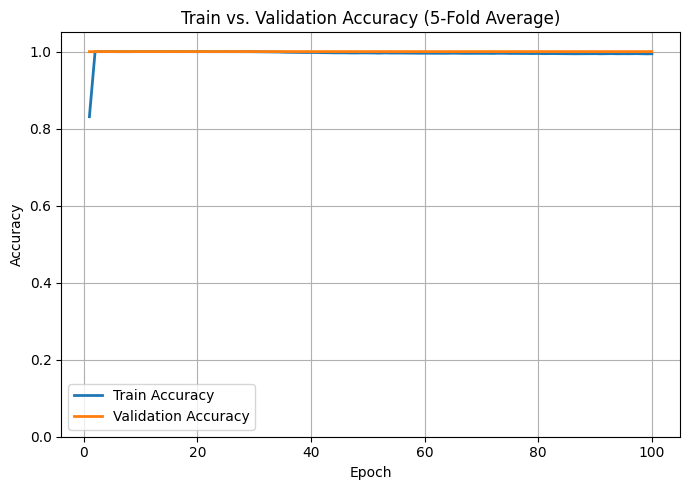

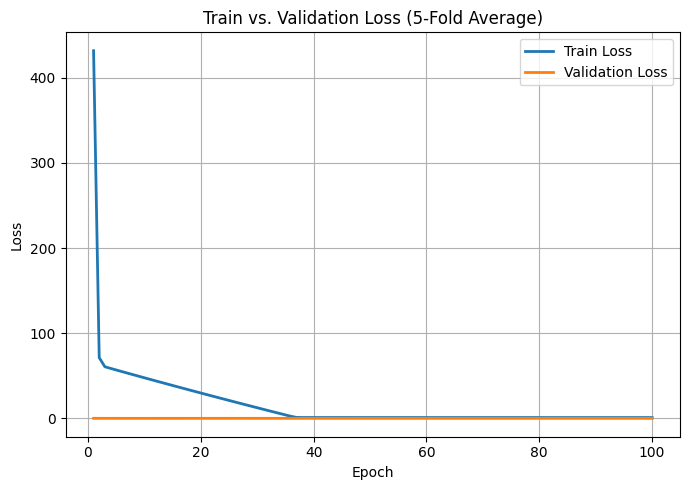

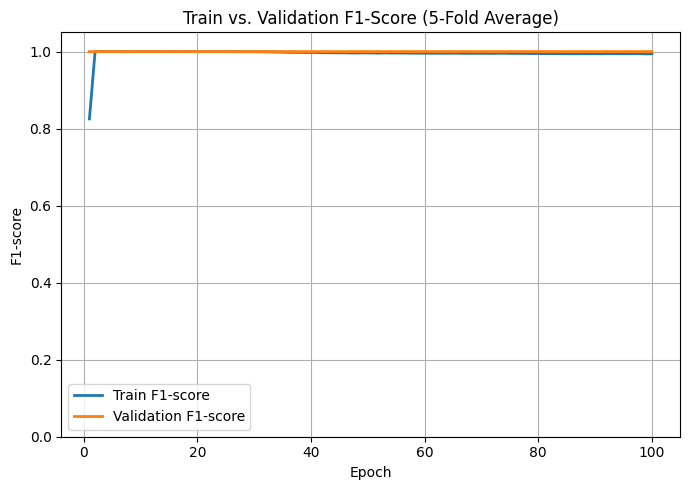

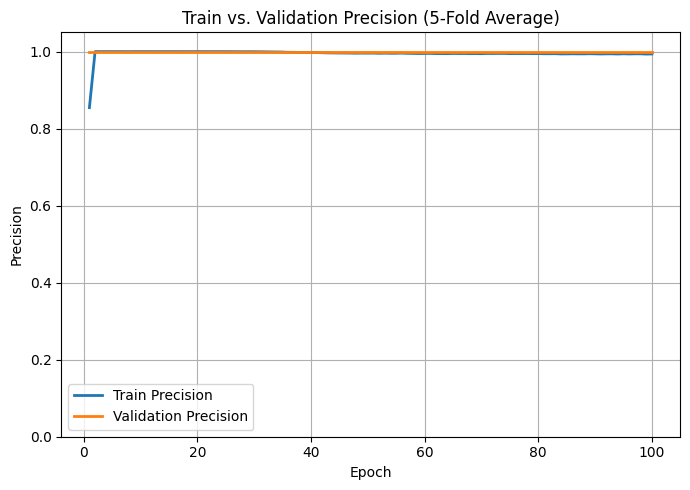

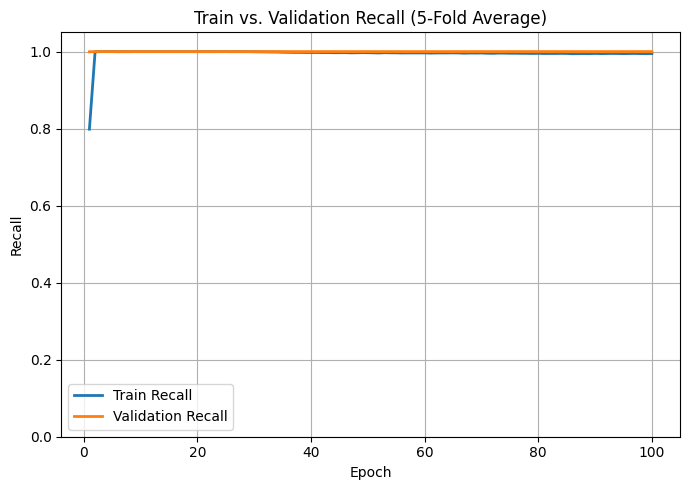

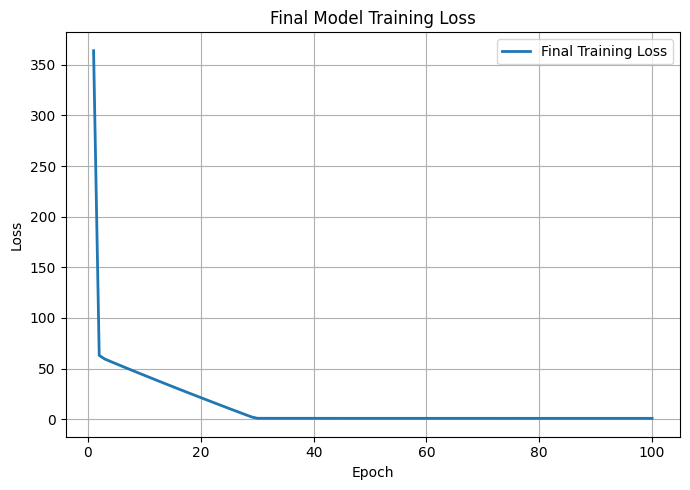


===== Per-Fold Validation Results =====
   fold  val_accuracy  val_precision  val_recall  val_f1
0     1           1.0            1.0         1.0     1.0
1     2           1.0            1.0         1.0     1.0
2     3           1.0            1.0         1.0     1.0
3     4           1.0            1.0         1.0     1.0
4     5           1.0            1.0         1.0     1.0

===== Mean Validation Results =====
val_accuracy     1.0
val_precision    1.0
val_recall       1.0
val_f1           1.0
dtype: float64

===== Independent Test Results =====
                         0
test_loss          0.02829
test_accuracy      1.00000
test_precision     1.00000
test_recall        1.00000
test_f1            1.00000
true_negative   5503.00000
false_positive     0.00000
false_negative     0.00000
true_positive   5502.00000
l1_reg             0.01000
l2_reg             0.00050


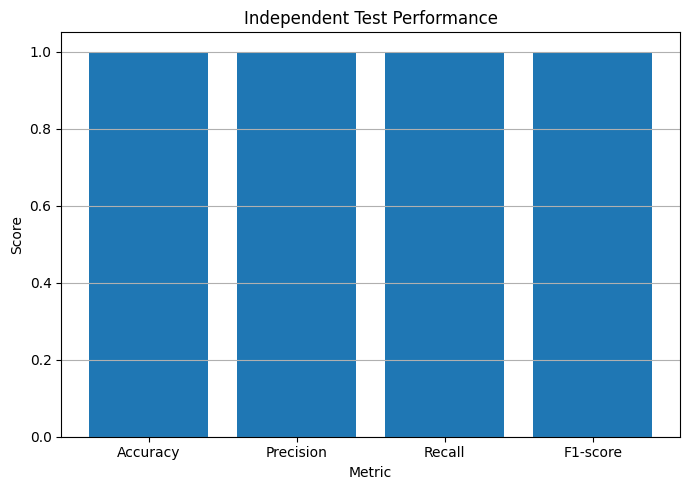

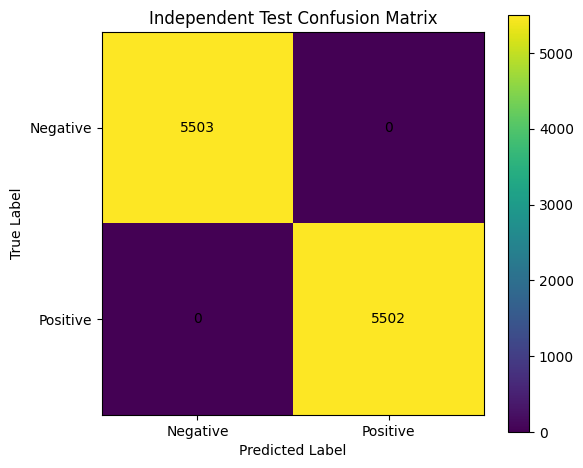


Plots were saved to: /content/drive/MyDrive/riboMoE_outputs


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


OUTPUT_DIR = "/content/drive/MyDrive/riboMoE_outputs"

if not os.path.exists(OUTPUT_DIR):
    raise FileNotFoundError(
        f"Could not find output directory: {OUTPUT_DIR}"
    )

# load metrics

train_losses_list = []
val_losses_list = []

train_accuracy_list = []
val_accuracy_list = []

train_precision_list = []
val_precision_list = []

train_recall_list = []
val_recall_list = []

train_f1_list = []
val_f1_list = []

for fold in range(1, 6):
    train_losses_list.append(
        np.load(f"{OUTPUT_DIR}/train_losses_fold{fold}.npy")
    )
    val_losses_list.append(
        np.load(f"{OUTPUT_DIR}/val_losses_fold{fold}.npy")
    )

    train_accuracy_list.append(
        np.load(f"{OUTPUT_DIR}/train_accuracy_fold{fold}.npy")
    )
    val_accuracy_list.append(
        np.load(f"{OUTPUT_DIR}/val_accuracy_fold{fold}.npy")
    )

    train_precision_list.append(
        np.load(f"{OUTPUT_DIR}/train_precision_fold{fold}.npy")
    )
    val_precision_list.append(
        np.load(f"{OUTPUT_DIR}/val_precision_fold{fold}.npy")
    )

    train_recall_list.append(
        np.load(f"{OUTPUT_DIR}/train_recall_fold{fold}.npy")
    )
    val_recall_list.append(
        np.load(f"{OUTPUT_DIR}/val_recall_fold{fold}.npy")
    )

    train_f1_list.append(
        np.load(f"{OUTPUT_DIR}/train_f1_fold{fold}.npy")
    )
    val_f1_list.append(
        np.load(f"{OUTPUT_DIR}/val_f1_fold{fold}.npy")
    )

# compute averages

train_losses_avg = np.mean(train_losses_list, axis=0)
val_losses_avg = np.mean(val_losses_list, axis=0)

train_accuracy_avg = np.mean(train_accuracy_list, axis=0)
val_accuracy_avg = np.mean(val_accuracy_list, axis=0)

train_precision_avg = np.mean(train_precision_list, axis=0)
val_precision_avg = np.mean(val_precision_list, axis=0)

train_recall_avg = np.mean(train_recall_list, axis=0)
val_recall_avg = np.mean(val_recall_list, axis=0)

train_f1_avg = np.mean(train_f1_list, axis=0)
val_f1_avg = np.mean(val_f1_list, axis=0)

epochs = range(1, len(train_losses_avg) + 1)

# train vs validation accuracy plot

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_accuracy_avg,
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    epochs,
    val_accuracy_avg,
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Train vs. Validation Accuracy (5-Fold Average)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/accuracy_5fold_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# train vs validation loss

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_losses_avg,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    epochs,
    val_losses_avg,
    label="Validation Loss",
    linewidth=2
)

plt.title("Train vs. Validation Loss (5-Fold Average)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/loss_5fold_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
# train vs validation loss f1-score

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_f1_avg,
    label="Train F1-score",
    linewidth=2
)

plt.plot(
    epochs,
    val_f1_avg,
    label="Validation F1-score",
    linewidth=2
)

plt.title("Train vs. Validation F1-Score (5-Fold Average)")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/f1_5fold_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# train vs validation precision

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_precision_avg,
    label="Train Precision",
    linewidth=2
)

plt.plot(
    epochs,
    val_precision_avg,
    label="Validation Precision",
    linewidth=2
)

plt.title("Train vs. Validation Precision (5-Fold Average)")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/precision_5fold_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# train vs validation recall

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_recall_avg,
    label="Train Recall",
    linewidth=2
)

plt.plot(
    epochs,
    val_recall_avg,
    label="Validation Recall",
    linewidth=2
)

plt.title("Train vs. Validation Recall (5-Fold Average)")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/recall_5fold_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# final model training loss

final_losses = np.load(
    f"{OUTPUT_DIR}/train_losses_final.npy"
)

final_epochs = range(1, len(final_losses) + 1)

plt.figure(figsize=(7, 5))

plt.plot(
    final_epochs,
    final_losses,
    label="Final Training Loss",
    linewidth=2
)

plt.title("Final Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/final_model_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# load + display cv summary

cv_summary_path = f"{OUTPUT_DIR}/cv_fold_summary.csv"

if os.path.exists(cv_summary_path):
    cv_summary = pd.read_csv(cv_summary_path)

    print("\n===== Per-Fold Validation Results =====")
    print(cv_summary)

    print("\n===== Mean Validation Results =====")
    print(
        cv_summary[
            [
                "val_accuracy",
                "val_precision",
                "val_recall",
                "val_f1"
            ]
        ].mean()
    )
else:
    print(
        f"\nCV summary file not found: {cv_summary_path}"
    )


test_results_path = (
    f"{OUTPUT_DIR}/moe_independent_test_results.csv"
)

if os.path.exists(test_results_path):
    test_results = pd.read_csv(test_results_path)

    print("\n===== Independent Test Results =====")
    print(test_results.T)
else:
    print(
        f"\nTest results file not found: {test_results_path}"
    )

#plot indpendent test metrics
if os.path.exists(test_results_path):
    metric_names = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]

    metric_values = [
        test_results.loc[0, "test_accuracy"],
        test_results.loc[0, "test_precision"],
        test_results.loc[0, "test_recall"],
        test_results.loc[0, "test_f1"]
    ]

    plt.figure(figsize=(7, 5))

    plt.bar(
        metric_names,
        metric_values
    )

    plt.title("Independent Test Performance")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/independent_test_metrics.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# plot confusion matrix

confusion_matrix_path = (
    f"{OUTPUT_DIR}/test_confusion_matrix.npy"
)

if os.path.exists(confusion_matrix_path):
    test_cm = np.load(confusion_matrix_path)

    plt.figure(figsize=(6, 5))

    plt.imshow(test_cm)
    plt.title("Independent Test Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(test_cm.shape[0]):
        for j in range(test_cm.shape[1]):
            plt.text(
                j,
                i,
                str(test_cm[i, j]),
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/independent_test_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print(
        f"\nConfusion matrix file not found: "
        f"{confusion_matrix_path}"
    )

print(
    f"\nPlots were saved to: {OUTPUT_DIR}"
)